In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext autoreload
%autoreload 2

In [2]:
from typing import Literal
from typing_extensions import TypedDict

class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows

    Attributes:
        content: Short specific description of task
        status: Current state -  pending, in_progress, or completed
    """

    content: str
    status: Literal["pending", "in_progress", "completed"]

In [3]:
def file_reducer(left, right):
    """Merge two file dictionaries, with the right side taking precedence.
    Used as a reducer function for the file field in agent state,a
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side of dictionary (existing files)
        right: Ride side of dictionary (new/updated files)

    Returns:
        Merged dictionaries with right values overriding left values
    """

    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}

In [4]:
from langchain.agents import AgentState
from typing import NotRequired, Annotated

class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system
    
    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items from task planning and progress tracking
    - files: Virtula file system stored as dict mapping filenames to content
    """
    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str,str]], file_reducer]

In [5]:
from utils.utils import show_prompt

from prompts.prompts import WRITE_TODOS_DESCRIPTION

show_prompt(WRITE_TODOS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Create and manage structured task lists for tracking progress through complex workflows.                       │
│                                                                                                                 │
│  ## When to Use                                                                                                 │
│  - Multi-step or non-trivial tasks requiring coordination                                                       │
│  - When user provides multiple tasks or explicitly requests todo list                                           │
│  - Avoid for single, trivial actions unless directed otherwise                                                  │
│                                                                                                                 │
│  ## Structure                                                                                                   │
│  - Maintain one list containing multiple todo objects (content, status, id)                                     │
│  - Use clear, actionable content descriptions                                                                   │
│  - Status must be: pending, in_progress, or completed                                                           │
│                                                                                                                 │
│  ## Best Practices                                                                                              │
│  - Only one in_progress task at a time                                                                          │
│  - Mark completed immediately when task is fully done                                                           │
│  - Always send the full updated list when making changes                                                        │
│  - Prune irrelevant items to keep list focused                                                                  │
│                                                                                                                 │
│  ## Progress Updates                                                                                            │
│  - Call TodoWrite again to change task status or edit content                                                   │
│  - Reflect real-time progress; don't batch completions                                                          │
│  - If blocked, keep in_progress and add new task describing blocker                                             │
│                                                                                                                 │
│  ## Parameters                                                                                                  │
│  - todos: List of TODO items with content and status fields                                                     │
│                                                                                                                 │
│  ## Returns                                                                                                     │
│  Updates agent state with new todo list.                                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Write and read TODO tool list

In [6]:
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.types import Command
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import InjectedState

@tool(description=WRITE_TODOS_DESCRIPTION, parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of todo items with content and status
        tool_call_id: Tool call identifier for message response
    
        Returns:
            Command to update agent state with new TODO list
    """

    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )

@tool(parse_docstring=True)
def read_todos(
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> str:
    """Read the current TODO list from the agent state.
    
    This tool allows the agent to retrieve and review the current TODO list
    to stay focussed on remaining tasks and track priogress through complex workflows.
    
    Args:
        state: Injected agent state containing the current TODO list
        tool_call_id: Injected tool call identifier fir message tracking

    Returns:
        Formatted string representation of current TODO list
    """ 

    todos = state.get("todos", [])
    if not todos:
        return "No todos currently in list."
    
    result = "Current TODO List: \n"
    status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
    for i, todo in enumerate(todos, 1):
        emoji = status_emoji.get(todo["status"], "❓")
        result += f"{i}. {emoji} {todo['content']} ({todo['status']})\n"
    
    return result.strip()

In [8]:
from prompts.prompts import TODO_USAGE_INSTRUCTIONS

show_prompt(TODO_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [10]:
# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """

@tool(parse_docstring=True)
def web_search(query: str):
    """Search the web for information on a specific topic.
    
    This tool performs web searches and wreturns relevant results for the given query.
    Use this when you need to gather information from internet about any topic.
    
    Args:
        query: The search query string. Be specific and clear about what information you are looking for.
    
    Returns:
        Search results from search engine.
    
    Example:
        web_search("machine learning application in healthcare)
    """
    return search_result

In [15]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

model = init_chat_model(model="anthropic:claude-sonnet-4-20250514", temperature=0.0)
tools = [write_todos, read_todos, web_search]

SIMPLE_RESEARCH_INSTRUCTIONS = """Important: Just make a single call to the web searc tool and use the result provided by the tool to answer to the user's question."""

agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" *80
    +"\n\n"
    + SIMPLE_RESEARCH_INSTRUCTIONS,
    state_schema=DeepAgentState
)

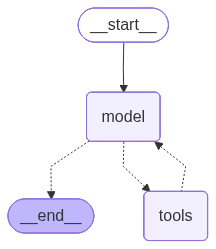

In [17]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [18]:
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Give me a short summary of the Model Context Protocol (MCP)."
    }]
})

In [20]:
from utils.utils import format_message
format_message(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me a short summary of the Model Context Protocol (MCP).                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll help you get a summary of the Model Context Protocol (MCP). Let me search for current information about    │
│ it.                                                                                                             │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Search for information about Model Context Protocol (MCP) and provide a short summary",       │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_01JYaaGzZ6Yof4BgwZr5CGwV                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Search for information about Model Context Protocol (MCP) and provide a      │
│ short summary', 'status': 'pending'}]                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP overview summary"                                                        │
│ }                                                                                                               │
│    ID: toolu_01KttpXrPUz5jNkeZbgZZkhC                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ The Model Context Protocol (MCP) is an open standard protocol developed                                         │
│ by Anthropic to enable seamless integration between AI models and external systems like                         │
│ tools, databases, and other services. It acts as a standardized communication layer,                            │
│ allowing AI models to access and utilize data from various sources in a consistent and                          │
│ efficient manner. Essentially, MCP simplifies the process of connecting AI assistants                           │
│ to external services by providing a unified language for data exchange.                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: toolu_01LT7zh1YSTYNZMMs4Q8AqAJ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. ⏳ Search for information about Model Context Protocol (MCP) and provide a short summary (pending)           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Search for information about Model Context Protocol (MCP) and provide a short summary",       │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_01Go5gxmZr6cZWfb8NaaRToa                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Search for information about Model Context Protocol (MCP) and provide a      │
│ short summary', 'status': 'completed'}]                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## Model Context Protocol (MCP) Summary                                                                         │
│                                                                                                                 │
│ The **Model Context Protocol (MCP)** is an open standard protocol developed by Anthropic that serves as a       │
│ standardized communication layer between AI models and external systems. Here are the key points:               │
│                                                                                                                 │
│ **Purpose**: MCP enables seamless integration between AI assistants and various external services including:    │
│ - Tools and applications                                                                                        │
│ - Databases                                                                                                     │
│ - APIs and other services                                                                                       │
│                                                                                                                 │
│ **Key Benefits**:                                                                                               │
│ - **Standardization**: Provides a unified language for data exchange                                            │
│ - **Simplification**: Streamlines the process of connecting AI models to external resources                     │
│ - **Efficiency**: Enables consistent and efficient data access across different systems                         │
│                                                                                                                 │
│ **Function**: It acts as a bridge that allows AI models to access and utilize data from various sources in a    │
│ standardized way, eliminating the need for custom integrations for each service.                                │
│                                                                                                                 │
│ In essence, MCP is designed to make it easier for AI assistants to interact with the broader digital ecosystem  │
│ by providing a common protocol for communication and data exchange.                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯